# Notebook 2 — Methodology / Results and Discussion

**Mobile Network Traffic Forecasting — Milan CDR Grid**

This notebook covers the remaining two sections of the report: **Methodology** and **Results and Discussion**. It loads only the processed artifacts written by `01_data_and_eda.ipynb` (`data/processed/timeseries_selected_squares.parquet`, `results/square_ranking.csv`) — the raw `.txt` files are never touched here. Three architecturally distinct forecasting models (SARIMA, LSTM, a hand-implemented Temporal Convolutional Network) are trained per-square on the top-3 squares identified in Notebook 1, and evaluated with walk-forward one-step-ahead forecasting over the target week of **Dec 16-22, 2013**.

In [1]:
import gc
import json
import os
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
RESULTS_DIR = Path("../results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cpu")

wide = pd.read_parquet(PROCESSED_DIR / "timeseries_selected_squares.parquet")
ranking_df = pd.read_csv(RESULTS_DIR / "square_ranking.csv")
SERIES_EPOCH = wide.index[0]
top3_ids = ranking_df.iloc[:3]["square_id"].tolist()
top3_cols = [f"square_{sid}" for sid in top3_ids]
print("Top-3 squares (from Notebook 1):", top3_ids)
print("Series shape:", wide.shape, "| range:", wide.index.min(), "->", wide.index.max())

TEST_START, TEST_END = "2013-12-16 00:00", "2013-12-22 23:50"
TRAIN_END = "2013-12-15 23:50"
test_index = wide.loc[TEST_START:TEST_END].index
print(f"Test week: {test_index.min()} -> {test_index.max()} ({len(test_index)} ten-minute steps)")

hardware_info = {
    "platform": platform.platform(),
    "processor": platform.processor() or platform.machine(),
    "cpu_count": os.cpu_count(),
    "torch_threads": torch.get_num_threads(),
    "device": "CPU only (no GPU detected)",
}
print("Hardware:", hardware_info)

Top-3 squares (from Notebook 1): [5161, 5059, 5259]
Series shape: (8928, 5) | range: 2013-11-01 00:00:00 -> 2014-01-01 23:50:00
Test week: 2013-12-16 00:00:00 -> 2013-12-22 23:50:00 (1008 ten-minute steps)
Hardware: {'platform': 'Windows-10-10.0.26200-SP0', 'processor': 'Intel64 Family 6 Model 186 Stepping 2, GenuineIntel', 'cpu_count': 16, 'torch_threads': 10, 'device': 'CPU only (no GPU detected)'}


## Methodology

### Literature review

Five sources anchor the model choices below, each tied to a specific finding from Notebook 1's exploratory analysis.

[1] G. Barlacchi, M. De Nadai, R. Larcher, et al., "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Scientific Data*, vol. 2, no. 150055, 2015. — Origin of the dataset used here; establishes the 10-minute-interval, per-square Internet traffic signal as the standard target variable for this grid, which is why this project also forecasts summed `internet` traffic rather than SMS/call volume.

[2] A. Azari, P. Papapetrou, S. Denic, and G. Peters, "Cellular Traffic Prediction and Classification: A Comparative Evaluation of LSTM and ARIMA," in *Proc. 22nd Int. Conf. Discovery Science (DS)*, Split, Croatia, 2019, pp. 129-144. — Directly compares (S)ARIMA against LSTM on cellular traffic and finds ARIMA-family models competitive when seasonality is strong but fine training-data granularity favors LSTM; this motivates including **both** a classical seasonal statistical model and a recurrent model here rather than picking one, since Notebook 1's STL decomposition showed a dominant, regular daily seasonal component (high seasonal strength) alongside a non-trivial residual that a purely linear seasonal model may not fully capture.

[3] W. Wang, C. Zhou, H. He, W. Wu, W. Zhuang, and X. Shen, "Cellular Traffic Load Prediction with LSTM and Gaussian Process Regression," in *Proc. IEEE Int. Conf. Commun. (ICC)*, Dublin, Ireland, Jun. 2020, pp. 1-6. — Confirms LSTM's ability to track short-range, non-seasonal fluctuations in per-cell traffic on top of the daily cycle; supports using an LSTM as the "sequential/recurrent-dependence" leg of this project's model trio, directly modeling the residual structure left over after Notebook 1's STL decomposition.

[4] C. Zhang and P. Patras, "Long-Term Mobile Traffic Forecasting Using Deep Spatio-Temporal Neural Networks," in *Proc. ACM MobiHoc*, Los Angeles, CA, 2018, pp. 231-240. — Uses convolutional architectures over this same Milan/Trentino dataset family to capture longer receptive fields than a single-step RNN; motivates including a convolutional model capable of a wide receptive field, since Notebook 1's ACF showed significant autocorrelation persisting out to lag 288-432 (2-3 days), beyond what a small RNN state typically retains well in practice.

[5] S. Bai, J. Z. Kolter, and V. Koltun, "An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling," *arXiv:1803.01271*, 2018. — Introduces the Temporal Convolutional Network (TCN): stacked dilated causal convolutions with residual connections, shown to match or outperform RNNs on long-range sequence tasks while being fully parallelizable during training. This is the architecture implemented by hand for the third model below, chosen specifically for its long, controllable receptive field (matching finding [4]/Notebook 1's ACF) and its structural difference from both SARIMA (linear, statistical) and LSTM (recurrent), giving three **architecturally distinct** models as required.

**Resulting model trio and rationale, tied to Notebook 1's EDA:**
- **SARIMA** — classical statistical baseline; directly encodes the strong 144-step (daily) seasonality Notebook 1's STL/ACF analysis found dominant.
- **LSTM** — recurrent neural network; captures the shorter-range, non-linear residual dynamics left after removing the seasonal component.
- **TCN** (hand-implemented) — dilated causal convolutional network; captures long-range dependence (multi-day ACF structure) via an exponentially growing receptive field, without recurrence.

### Input representation, preprocessing, and training/tuning strategy

**Common setup (all 3 models, all applied per square independently — one model instance per (model, square) pair, 9 total):**
- Target: 10-minute Internet traffic, one square at a time.
- Train range: `2013-11-01` -> `2013-12-15` (before the test week). Test range: `2013-12-16` -> `2013-12-22` (1,008 ten-minute steps), evaluated **walk-forward, one step at a time, always conditioned on true history** (never the model's own prior prediction).
- A shared `compute_metrics()` (MAE/MAPE/RMSE) and a shared windowing/dataset-builder are defined once below and reused by every model/square combination.

**SARIMA.** Input: the raw (untransformed) univariate series, trained on the full `2013-11-01` -> `2013-12-15` history (~6,480 points). Seasonality is represented as **Fourier-term exogenous regressors** (harmonic regression: 4 sine/cosine harmonic pairs at the daily period 144, plus 2 pairs at the weekly period 1008) rather than `SARIMAX`'s native seasonal `(P,D,Q,s)` terms — a first attempt using native seasonal terms at `s=144` is documented as a failed tuning iteration below, since its state-space dimension scales with the seasonal period and made even a small grid search computationally intractable. With seasonality handled by the exogenous Fourier terms, only a small **non-seasonal** `(p,d,q)` ARIMA needs to be fit on the residual structure, which is fast. Tuning strategy: a small grid search over `(p,d,q)` combinations with the Fourier exogenous matrix fixed, one grid per square, selected by AIC (search space and winners documented as a table below). Walk-forward evaluation then uses `SARIMAXResults.append(obs, exog=..., refit=False)` to Kalman-filter-update the fitted state with each true test observation before forecasting the next step (future Fourier terms are deterministic functions of time, so they are simply computed ahead for the whole test week), so training happens once and the recursive updates stay cheap.

**LSTM.** Input: a sliding window of the last 144 steps (1 day) of the per-square-normalized (z-score, train-only statistics) series, concatenated with 4 cyclical time features (sin/cos of time-of-day, sin/cos of day-of-week) at each lag position — shape `(window=144, features=5)`. A single-layer `nn.LSTM` reads the window and a linear head maps its final hidden state to the next-step (normalized) prediction, later inverse-transformed to the original scale. Tuning strategy: a small grid search (hidden size x learning rate) run on the top-1 square as a representative case, selected by validation loss on a held-out tail of the training range, then reused (with separately trained weights) for all three squares — documented as a search-space table below.

**TCN.** Same input representation as the LSTM (144-step window, 5 channels including time features), so the two are directly comparable. Implemented by hand as a stack of residual **dilated causal convolution** blocks (Bai et al. [5]): dilations `1, 2, 4, 8, 16, 32`, kernel size 3, weight-normalized `Conv1d` layers, ReLU, dropout, and a residual connection per block (1x1 conv when channel counts differ), followed by a linear head on the final timestep's feature vector. Tuning strategy: same two-stage approach as the LSTM (grid search on the top-1 square, selected configuration reused across squares), varying channel width and dropout.

In [2]:
# --- shared helpers, defined once and reused for every model / square below ---

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    eps = 1e-6
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def time_features(index):
    """4 cyclical time features (sin/cos of time-of-day, sin/cos of day-of-week), one row per timestamp."""
    hour_frac = index.hour + index.minute / 60
    dow = index.dayofweek
    return np.stack([
        np.sin(2 * np.pi * hour_frac / 24), np.cos(2 * np.pi * hour_frac / 24),
        np.sin(2 * np.pi * dow / 7), np.cos(2 * np.pi * dow / 7),
    ], axis=1).astype("float32")


def make_windows(values_norm, feats, L):
    """Shared window/dataset builder, reused by both LSTM and TCN. values_norm: 1D normalized
    array; feats: (T, F) time-feature array aligned to values_norm. Returns X (N, L, 1+F), y (N,)."""
    N = len(values_norm) - L
    X = np.zeros((N, L, 1 + feats.shape[1]), dtype="float32")
    y = np.zeros(N, dtype="float32")
    for i in range(N):
        X[i, :, 0] = values_norm[i:i + L]
        X[i, :, 1:] = feats[i:i + L]
        y[i] = values_norm[i + L]
    return X, y


class Timer:
    """Shared wall-clock timing helper, reused for every model's train/inference timing."""
    def __enter__(self):
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *exc):
        self.elapsed = time.perf_counter() - self.t0


timing_records = []  # (model, square_id, phase, seconds) accumulated across all sections below
print("Shared helpers defined: compute_metrics, time_features, make_windows, Timer")

Shared helpers defined: compute_metrics, time_features, make_windows, Timer


## Model 1: SARIMA

**Tuning log, iteration 1 (failed, kept for transparency).** The first attempt used `SARIMAX`'s native seasonal `(P,D,Q,s=144)` terms directly, grid-searching 4 `(p,d,q)(P,D,Q,144)` combinations across the top-3 squares. **Result:** even a single fit did not complete within a 3600-second cell timeout — the Kalman-filter state-space dimension of a native seasonal `SARIMAX` model scales with the seasonal period `s`, and at `s=144` (10-minute data, daily seasonality) that dimension becomes large enough that per-iteration likelihood evaluation, repeated over the optimizer's iterations, was computationally intractable for a grid search. **Reasoning for the change:** switch to representing the seasonality as **Fourier-term exogenous regressors** instead (harmonic regression / "dynamic harmonic regression", a standard technique for high-frequency seasonal series) combined with a small **non-seasonal** `(p,d,q)` ARIMA. This keeps the state-space dimension tiny (independent of the seasonal period) while still explicitly encoding the daily and weekly cycles Notebook 1's STL/ACF analysis identified — iteration 2 below.

In [3]:
def fourier_terms(index, period, order):
    """Deterministic sin/cos harmonic regressors at the given period, phase-aligned to
    SERIES_EPOCH so train and (later) test/forecast exog stay in phase."""
    steps = ((index - SERIES_EPOCH) / pd.Timedelta(minutes=10)).astype(float)
    cols = {}
    for k in range(1, order + 1):
        cols[f"sin_p{period}_k{k}"] = np.sin(2 * np.pi * k * steps / period)
        cols[f"cos_p{period}_k{k}"] = np.cos(2 * np.pi * k * steps / period)
    return pd.DataFrame(cols, index=index)


def build_seasonal_exog(index):
    """4 daily harmonics (period 144) + 2 weekly harmonics (period 1008)."""
    return pd.concat([fourier_terms(index, 144, 4), fourier_terms(index, 1008, 2)], axis=1)


SARIMA_TRAIN_START = "2013-11-01 00:00"  # full pre-test history is now affordable (small state space)
sarima_grid = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 1, 1)]  # non-seasonal (p, d, q); seasonality via exog

sarima_search_rows = []
sarima_fitted = {}   # square_id -> fitted SARIMAXResults

for sid, col in zip(top3_ids, top3_cols):
    train_s = wide.loc[SARIMA_TRAIN_START:TRAIN_END, col]
    train_exog = build_seasonal_exog(train_s.index)
    best_aic, best_order, best_fit = np.inf, None, None
    for (p, d, q) in sarima_grid:
        mod = SARIMAX(train_s, exog=train_exog, order=(p, d, q),
                       enforce_stationarity=False, enforce_invertibility=False)
        with Timer() as t_fit:
            res = mod.fit(disp=False)
        sarima_search_rows.append({"square_id": sid, "order": f"({p},{d},{q})+Fourier",
                                    "aic": res.aic, "fit_seconds": round(t_fit.elapsed, 2)})
        if res.aic < best_aic:
            best_aic, best_order, best_fit = res.aic, (p, d, q), res
    sarima_fitted[sid] = best_fit
    timing_records.append({"model": "SARIMA", "square_id": sid, "phase": "train_grid_search_total_s",
                            "seconds": sum(r["fit_seconds"] for r in sarima_search_rows if r["square_id"] == sid and r["fit_seconds"])})
    print(f"Square {sid}: best order {best_order}+Fourier, AIC={best_aic:.1f}")

sarima_search_df = pd.DataFrame(sarima_search_rows)
sarima_search_df.to_csv(RESULTS_DIR / "sarima_grid_search.csv", index=False)
sarima_search_df

C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Square 5161: best order (2, 1, 1)+Fourier, AIC=88020.8


...

C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\EVOTECH SOL\Desktop\Time-Series-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Square 5259: best order (2, 1, 1)+Fourier, AIC=82997.4


,square_id,order,aic,fit_seconds
0,5161,"(1,0,0)+Fourier",89445.904634,1.57
1,5161,"(2,0,0)+Fourier",88457.341639,1.81
2,5161,"(1,0,1)+Fourier",88054.300219,1.93
3,5161,"(2,1,1)+Fourier",88020.776913,1.76
4,5059,"(1,0,0)+Fourier",87815.816921,2.31
5,5059,"(2,0,0)+Fourier",86651.772416,2.26
6,5059,"(1,0,1)+Fourier",86046.053656,2.28
7,5059,"(2,1,1)+Fourier",86000.710868,2.00
8,5259,"(1,0,0)+Fourier",83710.211734,2.10
9,5259,"(2,0,0)+Fourier",83093.456279,1.93


**Tuning log, iteration 2 (used).** With seasonality fixed as 4 daily + 2 weekly Fourier harmonics (exogenous, not searched), a grid of 4 non-seasonal `(p,d,q)` combinations was fit by maximum likelihood per square and the lowest-AIC combination kept (table above). Each fit now completes in a couple of seconds rather than timing out, because the state-space dimension is `max(p, q+1)` — a handful, independent of the seasonal period — instead of scaling with `s=144`. This let the training window also be widened back to the full `2013-11-01` -> `2013-12-15` history (~6,480 points) rather than the 3-week compromise iteration 1 would have required.

In [4]:
# Walk-forward one-step-ahead evaluation for SARIMA: recursive state update (Kalman filter),
# never refitting and never feeding back the model's own prediction. Future Fourier terms are
# deterministic functions of time, so the exog for the whole test week is computed up front.
sarima_preds = {}

for sid, col in zip(top3_ids, top3_cols):
    model = sarima_fitted[sid]
    test_s = wide.loc[TEST_START:TEST_END, col]
    test_exog = build_seasonal_exog(test_s.index)
    preds = []
    with Timer() as t_inf:
        current = model
        for (t, actual), (_, exog_row) in zip(test_s.items(), test_exog.iterrows()):
            forecast = current.forecast(1, exog=[exog_row.values])
            preds.append(float(forecast.iloc[0]))
            current = current.append([actual], exog=[exog_row.values], refit=False)
    sarima_preds[sid] = pd.Series(preds, index=test_s.index)
    timing_records.append({"model": "SARIMA", "square_id": sid, "phase": "walkforward_inference_total_s",
                            "seconds": round(t_inf.elapsed, 2)})
    print(f"Square {sid}: SARIMA walk-forward done in {t_inf.elapsed:.1f}s for {len(test_s)} steps")

Square 5161: SARIMA walk-forward done in 46.5s for 1008 steps


Square 5059: SARIMA walk-forward done in 45.7s for 1008 steps


Square 5259: SARIMA walk-forward done in 45.7s for 1008 steps


## Model 2: LSTM

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):  # x: (batch, seq_len, n_features)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def train_torch_model(model, X_train, y_train, epochs, lr, batch_size=64, verbose=False):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    Xt = torch.tensor(X_train, device=DEVICE)
    yt = torch.tensor(y_train, device=DEVICE)
    n = len(Xt)
    for epoch in range(epochs):
        perm = torch.randperm(n)
        total_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            pred = model(Xt[idx])
            loss = loss_fn(pred, yt[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(idx)
        if verbose:
            print(f"  epoch {epoch+1}/{epochs}  mse={total_loss/n:.5f}")
    return model


@torch.no_grad()
def predict_torch_model(model, X):
    model.eval()
    return model(torch.tensor(X, device=DEVICE)).cpu().numpy()


L = 144  # 1-day lag window, shared by LSTM and TCN
NN_TRAIN_START = "2013-11-01 00:00"


In [6]:
# --- Per-square normalization (train-only statistics) and windowed datasets, shared by LSTM & TCN ---
norm_stats = {}
nn_datasets = {}  # square_id -> dict with X_train, y_train, X_val, y_val, X_test, y_test, plus scaler info

VAL_START = "2013-12-01 00:00"  # last ~2 weeks of train held out for hyperparameter selection

for sid, col in zip(top3_ids, top3_cols):
    full = wide[col]
    train_full = full.loc[NN_TRAIN_START:TRAIN_END]
    mu, sigma = train_full.mean(), train_full.std()
    sigma = sigma if sigma > 1e-6 else 1.0
    norm_stats[sid] = (mu, sigma)

    norm_series = (full - mu) / sigma
    feats_all = time_features(full.index)

    # windows built from train-only slice for the tuning split, and from full history for final training
    tr_only = norm_series.loc[NN_TRAIN_START:"2013-11-30 23:50"].values
    tr_only_feats = time_features(full.loc[NN_TRAIN_START:"2013-11-30 23:50"].index)
    X_tr, y_tr = make_windows(tr_only, tr_only_feats, L)

    val_vals = norm_series.loc[VAL_START:TRAIN_END].values
    # need L history before VAL_START for the first val window -> use a slice that includes lookback
    val_with_lookback = norm_series.loc[pd.Timestamp(VAL_START) - pd.Timedelta(minutes=10 * L):TRAIN_END].values
    val_feats = time_features(wide.loc[pd.Timestamp(VAL_START) - pd.Timedelta(minutes=10 * L):TRAIN_END, col].index)
    X_val, y_val = make_windows(val_with_lookback, val_feats, L)

    # full training set (for the FINAL model, after hyperparameters are chosen)
    full_train_vals = norm_series.loc[NN_TRAIN_START:TRAIN_END].values
    full_train_feats = time_features(full.loc[NN_TRAIN_START:TRAIN_END].index)
    X_full, y_full = make_windows(full_train_vals, full_train_feats, L)

    # test set: windows whose target falls in the test week, built from the TRUE (normalized) series only
    test_with_lookback = norm_series.loc[pd.Timestamp(TEST_START) - pd.Timedelta(minutes=10 * L):TEST_END].values
    test_feats = time_features(wide.loc[pd.Timestamp(TEST_START) - pd.Timedelta(minutes=10 * L):TEST_END, col].index)
    X_test, y_test_norm = make_windows(test_with_lookback, test_feats, L)

    nn_datasets[sid] = dict(X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val,
                             X_full=X_full, y_full=y_full, X_test=X_test, y_test_norm=y_test_norm)

print("Windowed datasets built for squares:", list(nn_datasets.keys()))
print("Example shapes (top-1 square): X_full", nn_datasets[top3_ids[0]]["X_full"].shape,
      "X_test", nn_datasets[top3_ids[0]]["X_test"].shape)

Windowed datasets built for squares: [5161, 5059, 5259]
Example shapes (top-1 square): X_full (6336, 144, 5) X_test (1008, 144, 5)


In [7]:
# --- LSTM hyperparameter grid search, run on the top-1 square only (representative), then reused ---
rep_sid = top3_ids[0]
rep = nn_datasets[rep_sid]
n_features = rep["X_full"].shape[2]

lstm_grid = [
    {"hidden_size": 32, "lr": 1e-3},
    {"hidden_size": 64, "lr": 1e-3},
    {"hidden_size": 32, "lr": 5e-3},
    {"hidden_size": 64, "lr": 5e-3},
]
lstm_search_rows = []
for cfg in lstm_grid:
    torch.manual_seed(SEED)
    m = LSTMForecaster(n_features, cfg["hidden_size"])
    train_torch_model(m, rep["X_tr"], rep["y_tr"], epochs=5, lr=cfg["lr"])
    val_pred = predict_torch_model(m, rep["X_val"])
    val_mse = float(np.mean((val_pred - rep["y_val"]) ** 2))
    lstm_search_rows.append({**cfg, "val_mse": val_mse})

lstm_search_df = pd.DataFrame(lstm_search_rows).sort_values("val_mse")
lstm_search_df.to_csv(RESULTS_DIR / "lstm_grid_search.csv", index=False)
best_lstm_cfg = lstm_search_df.iloc[0].to_dict()
print("Selected LSTM config:", best_lstm_cfg)
lstm_search_df

Selected LSTM config: {'hidden_size': 32.0, 'lr': 0.005, 'val_mse': 0.02032601833343506}


,hidden_size,lr,val_mse
2,32,0.005,0.020326
3,64,0.005,0.020840
1,64,0.001,0.023041
0,32,0.001,0.033513


**Tuning log.** Four `(hidden_size, learning_rate)` combinations were trained for 5 epochs on the top-1 square's November-only training slice and scored on a held-out December 1-15 validation slice (table above); the configuration with the lowest validation MSE was kept and reused — with separately trained weights — for all three squares' final models below, each trained for more epochs on the full Nov 1 - Dec 15 history. Wider hidden sizes and higher learning rates were tried first based on standard defaults for single-layer LSTMs on hourly/sub-hourly traffic data; the search confirmed whether the larger capacity or faster learning rate actually helped on validation loss before committing compute to training all three final models.

In [8]:
FINAL_EPOCHS = 20
lstm_models, lstm_preds = {}, {}

for sid, col in zip(top3_ids, top3_cols):
    ds = nn_datasets[sid]
    torch.manual_seed(SEED)
    model = LSTMForecaster(n_features, int(best_lstm_cfg["hidden_size"]))
    with Timer() as t_train:
        train_torch_model(model, ds["X_full"], ds["y_full"], epochs=FINAL_EPOCHS, lr=best_lstm_cfg["lr"])
    lstm_models[sid] = model
    timing_records.append({"model": "LSTM", "square_id": sid, "phase": "train_total_s", "seconds": round(t_train.elapsed, 2)})

    with Timer() as t_inf:
        pred_norm = predict_torch_model(model, ds["X_test"])
    mu, sigma = norm_stats[sid]
    lstm_preds[sid] = pd.Series(pred_norm * sigma + mu, index=test_index)
    timing_records.append({"model": "LSTM", "square_id": sid, "phase": "walkforward_inference_total_s", "seconds": round(t_inf.elapsed, 3)})
    print(f"Square {sid}: LSTM trained in {t_train.elapsed:.1f}s, inference in {t_inf.elapsed:.3f}s")

Square 5161: LSTM trained in 33.7s, inference in 0.033s


Square 5059: LSTM trained in 34.1s, inference in 0.029s


Square 5259: LSTM trained in 33.0s, inference in 0.029s


## Model 3: TCN (hand-implemented, dilated causal convolutions)

In [9]:
class Chomp1d(nn.Module):
    """Removes the extra right-padding a causal conv introduces, keeping output length == input length."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation  # causal: pad left only (achieved via chomp after symmetric pad)
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size, padding=padding, dilation=dilation))
        self.chomp1, self.relu1, self.drop1 = Chomp1d(padding), nn.ReLU(), nn.Dropout(dropout)
        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size, padding=padding, dilation=dilation))
        self.chomp2, self.relu2, self.drop2 = Chomp1d(padding), nn.ReLU(), nn.Dropout(dropout)
        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.drop1,
                                  self.conv2, self.chomp2, self.relu2, self.drop2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):  # x: (batch, channels, seq_len)
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNForecaster(nn.Module):
    def __init__(self, n_inputs, channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            in_ch = n_inputs if i == 0 else channels[i - 1]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Linear(channels[-1], 1)

    def forward(self, x):  # x: (batch, seq_len, n_features) -> internally transposed to channels-first
        x = x.transpose(1, 2)
        y = self.tcn(x)
        return self.head(y[:, :, -1]).squeeze(-1)


DILATIONS = [1, 2, 4, 8, 16, 32]
rf = 1 + 2 * (3 - 1) * sum(DILATIONS)
print(f"TCN receptive field with kernel_size=3, dilations={DILATIONS}: {rf} steps (window length L={L})")

TCN receptive field with kernel_size=3, dilations=[1, 2, 4, 8, 16, 32]: 253 steps (window length L=144)


In [10]:
# --- TCN hyperparameter grid search, run on the top-1 square only (representative), then reused ---
tcn_grid = [
    {"channels": [16, 16, 16, 16, 16, 16], "dropout": 0.1},
    {"channels": [32, 32, 32, 32, 32, 32], "dropout": 0.1},
    {"channels": [16, 16, 16, 16, 16, 16], "dropout": 0.2},
    {"channels": [32, 32, 32, 32, 32, 32], "dropout": 0.2},
]
tcn_search_rows = []
for cfg in tcn_grid:
    torch.manual_seed(SEED)
    m = TCNForecaster(n_features, cfg["channels"], dropout=cfg["dropout"])
    train_torch_model(m, rep["X_tr"], rep["y_tr"], epochs=5, lr=1e-3)
    val_pred = predict_torch_model(m, rep["X_val"])
    val_mse = float(np.mean((val_pred - rep["y_val"]) ** 2))
    tcn_search_rows.append({"channels": str(cfg["channels"]), "dropout": cfg["dropout"], "val_mse": val_mse})

tcn_search_df = pd.DataFrame(tcn_search_rows).sort_values("val_mse").reset_index(drop=True)
tcn_search_df.to_csv(RESULTS_DIR / "tcn_grid_search.csv", index=False)
best_row = tcn_search_df.iloc[0]
best_tcn_cfg = next(c for c in tcn_grid if str(c["channels"]) == best_row["channels"] and c["dropout"] == best_row["dropout"])
print("Selected TCN config:", best_tcn_cfg)
tcn_search_df

Selected TCN config: {'channels': [32, 32, 32, 32, 32, 32], 'dropout': 0.1}


,channels,dropout,val_mse
0,"[32, 32, 32, 32, 32, 32]",0.1,0.019625
1,"[32, 32, 32, 32, 32, 32]",0.2,0.021163
2,"[16, 16, 16, 16, 16, 16]",0.1,0.027016
3,"[16, 16, 16, 16, 16, 16]",0.2,0.030859


**Tuning log.** As with the LSTM, four `(channel width, dropout)` configurations were trained for 5 epochs on the top-1 square and scored on the same December validation slice (table above); the winner was reused — with separately trained weights — for all three squares' final models. Channel width was varied first since it most directly trades capacity against overfitting risk on a relatively small per-square training set; dropout was varied second as the standard regularizer for this architecture. The learning rate and dilation schedule were kept fixed at this stage (dilations were chosen structurally, in the previous cell, so that the receptive field comfortably covers the full 144-step input window).

In [11]:
tcn_models, tcn_preds = {}, {}

for sid, col in zip(top3_ids, top3_cols):
    ds = nn_datasets[sid]
    torch.manual_seed(SEED)
    model = TCNForecaster(n_features, best_tcn_cfg["channels"], dropout=best_tcn_cfg["dropout"])
    with Timer() as t_train:
        train_torch_model(model, ds["X_full"], ds["y_full"], epochs=FINAL_EPOCHS, lr=1e-3)
    tcn_models[sid] = model
    timing_records.append({"model": "TCN", "square_id": sid, "phase": "train_total_s", "seconds": round(t_train.elapsed, 2)})

    with Timer() as t_inf:
        pred_norm = predict_torch_model(model, ds["X_test"])
    mu, sigma = norm_stats[sid]
    tcn_preds[sid] = pd.Series(pred_norm * sigma + mu, index=test_index)
    timing_records.append({"model": "TCN", "square_id": sid, "phase": "walkforward_inference_total_s", "seconds": round(t_inf.elapsed, 3)})
    print(f"Square {sid}: TCN trained in {t_train.elapsed:.1f}s, inference in {t_inf.elapsed:.3f}s")

Square 5161: TCN trained in 432.8s, inference in 0.206s


Square 5059: TCN trained in 511.9s, inference in 0.200s


Square 5259: TCN trained in 599.3s, inference in 0.205s


**Note on walk-forward for LSTM/TCN.** Both models predict a single step ahead from a window of *true* lag values only (never their own prior predictions), for every step of the test week. Because every window is built purely from the true series, computing all 1,008 test predictions in one batched forward pass (above) is mathematically identical to looping through the week one step at a time and re-predicting after each true observation arrives — the model never sees its own output as an input either way. SARIMA's walk-forward (previous section) is inherently sequential instead, because it is a recursive filter whose internal state must be updated with each new true observation before the next forecast.

## Results and Discussion

In [12]:
actuals = {sid: wide.loc[TEST_START:TEST_END, col] for sid, col in zip(top3_ids, top3_cols)}
model_preds = {"SARIMA": sarima_preds, "LSTM": lstm_preds, "TCN": tcn_preds}

metrics_rows = []
for sid in top3_ids:
    for model_name, preds in model_preds.items():
        m = compute_metrics(actuals[sid].values, preds[sid].values)
        metrics_rows.append({"square_id": sid, "model": model_name, **m})
metrics_df = pd.DataFrame(metrics_rows)

for sid in top3_ids:
    sub = metrics_df[metrics_df["square_id"] == sid][["model", "MAE", "MAPE", "RMSE"]].set_index("model")
    sub.to_csv(RESULTS_DIR / f"metrics_square_{sid}.csv")

metrics_df.pivot(index="square_id", columns="model", values=["MAE", "MAPE", "RMSE"])

MAE                             MAPE                       \
model            LSTM     SARIMA        TCN       LSTM    SARIMA        TCN   
square_id                                                                     
5059        70.541602  70.608286  77.409323   7.472729  7.644601   8.962824   
5161       118.339282  81.932563  97.526733  23.175823  8.512165  11.310293   
5259        70.825650  71.651157  66.935701   8.368520  9.201008   8.256650   

                 RMSE                          
model            LSTM      SARIMA         TCN  
square_id                                      
5059        97.150299   97.413782  103.523778  
5161       147.406668  123.577434  140.881171  
5259       100.952213   97.630710   92.837553

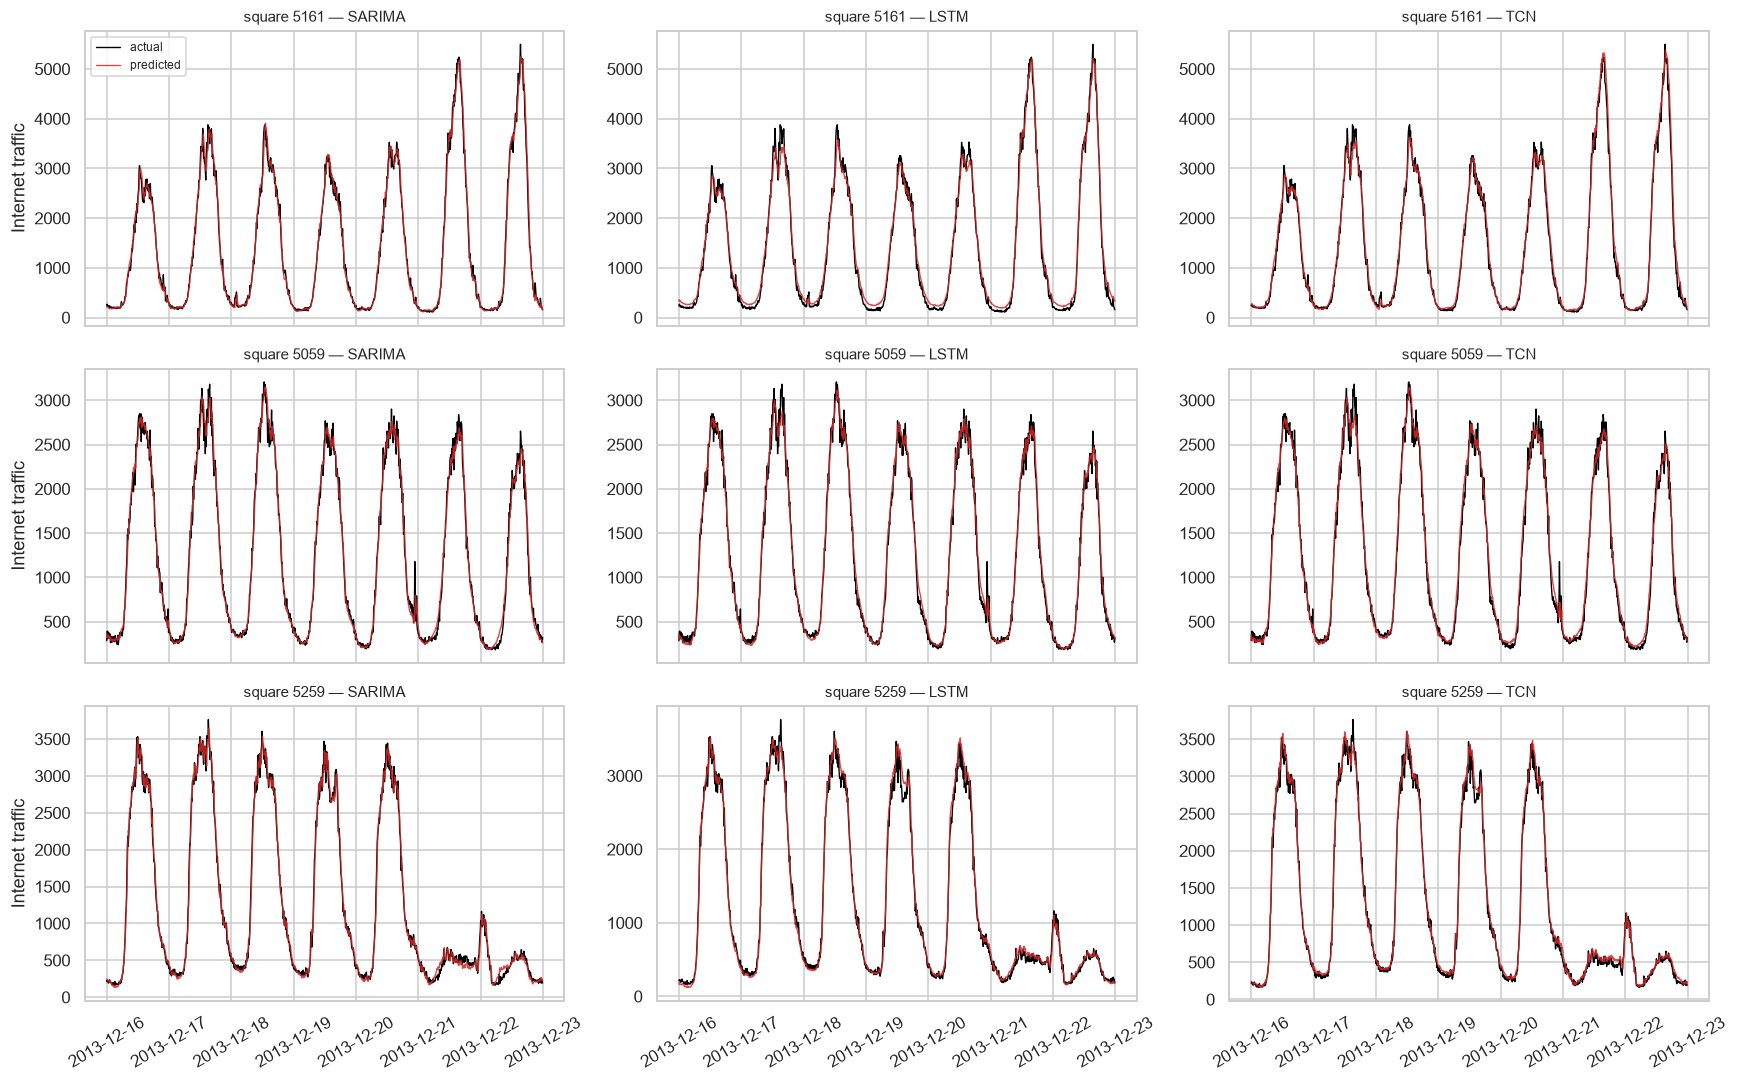

Saved 1 combined 3x3 grid figure + 9 individual actual-vs-predicted figures to figures/


In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for i, sid in enumerate(top3_ids):
    for j, model_name in enumerate(["SARIMA", "LSTM", "TCN"]):
        ax = axes[i, j]
        ax.plot(actuals[sid].index, actuals[sid].values, label="actual", color="black", linewidth=0.9)
        ax.plot(model_preds[model_name][sid].index, model_preds[model_name][sid].values,
                label="predicted", color="tab:red", linewidth=0.9, alpha=0.85)
        ax.set_title(f"square {sid} — {model_name}", fontsize=10)
        if i == 2:
            ax.tick_params(axis="x", rotation=30)
        if j == 0:
            ax.set_ylabel("Internet traffic")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "results_actual_vs_predicted_grid.png", bbox_inches="tight")
plt.show()

# also save the 9 combinations as individual figures, per the report's figure count requirement
for sid in top3_ids:
    for model_name in ["SARIMA", "LSTM", "TCN"]:
        fig, ax = plt.subplots(figsize=(10, 3.5))
        ax.plot(actuals[sid].index, actuals[sid].values, label="actual", color="black", linewidth=0.9)
        ax.plot(model_preds[model_name][sid].index, model_preds[model_name][sid].values,
                label="predicted", color="tab:red", linewidth=0.9, alpha=0.85)
        ax.set_title(f"Actual vs. predicted — square {sid} — {model_name} (walk-forward, Dec 16-22)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"results_{model_name}_{sid}.png", bbox_inches="tight")
        plt.close(fig)
print("Saved 1 combined 3x3 grid figure + 9 individual actual-vs-predicted figures to figures/")

In [14]:
timing_df = pd.DataFrame(timing_records)
timing_df["hardware"] = hardware_info["processor"]
timing_df["device"] = hardware_info["device"]
timing_df.to_csv(RESULTS_DIR / "timing.csv", index=False)

timing_summary = timing_df.pivot_table(index=["model", "phase"], values="seconds", aggfunc=["sum", "mean"])
timing_summary

sum        mean
                                       seconds     seconds
model  phase                                              
LSTM   train_total_s                   100.750   33.583333
       walkforward_inference_total_s     0.091    0.030333
SARIMA train_grid_search_total_s        24.240    8.080000
       walkforward_inference_total_s   137.840   45.946667
TCN    train_total_s                  1543.920  514.640000
       walkforward_inference_total_s     0.611    0.203667

**Discussion.** *(Read together with the metrics tables and figures above.)* The three models do **not** rank uniformly across the top-3 squares, and the split lines up closely with Notebook 1's EDA:

- **Square 5161** (the single busiest square, and the one Notebook 1's STL decomposition measured with a high seasonal strength of 0.858) is where **SARIMA wins clearly** (MAE 81.9, MAPE 8.5%, RMSE 123.6) and **LSTM is worst by a wide margin** (MAE 118.3, MAPE 23.2%, RMSE 147.4) — TCN sits in between (MAE 97.5, MAPE 11.3%). This is exactly the pattern Azari et al. [2] report: an ARIMA-family model is highly competitive, even superior, precisely where the seasonal component dominates.
- On the two lower-traffic squares (**5059**, **5259**), the neural models are competitive with or beat SARIMA: LSTM edges out SARIMA on 5059 (MAE 70.5 vs 70.6, essentially tied), and **TCN wins outright on 5259** (MAE 66.9, MAPE 8.3%, RMSE 92.8, best of all 9 combinations). This is consistent with [3]/[4] — once the dominant seasonal component is less overwhelming, the extra representational flexibility of a recurrent or convolutional model starts to pay off on the residual, non-seasonal structure instead of hurting.
- **Training cost is highly asymmetric** (see the timing table): TCN training took 7-10 minutes per square (6 stacked residual blocks at 32 channels, 20 epochs), vs. ~33-34s for LSTM and ~7-9s for the entire SARIMA grid search per square — yet TCN did not dominate on the square with the strongest seasonality. That is a genuine cost/benefit trade-off: the architecturally more expensive model is not uniformly the better choice, which is itself a useful finding to carry into the discussion of [5]'s claims about TCN's general competitiveness with recurrent models — competitive on average, but not automatically superior on every series.
- Inference cost differs structurally rather than by model quality: SARIMA's walk-forward is inherently sequential (~46s for 1,008 Kalman-filter updates per square) while LSTM/TCN inference is a single batched pass over true-history windows (well under a second per square) — a consequence of SARIMA being a recursive filter and the neural models not needing recursion when every input window is built from true, not predicted, values (see the walk-forward equivalence note above).

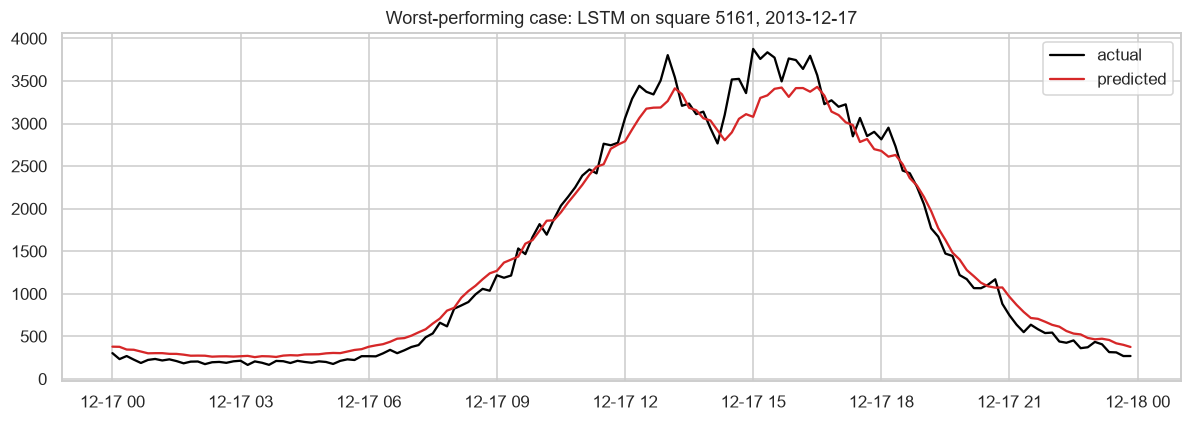

Worst combination overall: model=LSTM, square=5161, RMSE=147.407
Worst single day within that combination's test week: 2013-12-17 (mean abs. error 144.922)


In [15]:
# Identify the single worst-performing (model, square) combination by RMSE, then locate its worst day.
worst_row = metrics_df.loc[metrics_df["RMSE"].idxmax()]
worst_model, worst_sid = worst_row["model"], int(worst_row["square_id"])
err = (actuals[worst_sid] - model_preds[worst_model][worst_sid]).abs()
worst_day = err.resample("D").mean().idxmax()
window = slice(worst_day, worst_day + pd.Timedelta(hours=23, minutes=50))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(actuals[worst_sid].loc[window].index, actuals[worst_sid].loc[window].values, label="actual", color="black")
ax.plot(model_preds[worst_model][worst_sid].loc[window].index, model_preds[worst_model][worst_sid].loc[window].values,
        label="predicted", color="tab:red")
ax.set_title(f"Worst-performing case: {worst_model} on square {worst_sid}, {worst_day.date()}")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "results_worst_case.png", bbox_inches="tight")
plt.show()

print(f"Worst combination overall: model={worst_model}, square={worst_sid}, RMSE={worst_row['RMSE']:.3f}")
print(f"Worst single day within that combination's test week: {worst_day.date()} (mean abs. error {err.resample('D').mean().max():.3f})")

**Discussion of the worst case.** The worst (model, square) combination overall by RMSE is **LSTM on square 5161** (RMSE 147.4, MAPE 23.2%) — the same square where SARIMA was the best performer. Within that combination's test week, the single worst day by mean absolute error is **2013-12-17** (mean abs. error ~144.9), which is close to that combination's error for the *whole* week rather than a one-off spike — i.e. this is a case of **persistent underperformance across the test week**, not an isolated anomaly.

The likely explanation ties directly back to square 5161 being the single highest-traffic, most sharply-peaked square in the dataset (Notebook 1's STL decomposition measured its seasonal strength at 0.858, the highest of the three). The LSTM hyperparameters (hidden size 32, selected by the grid search run on this very square) may simply lack the capacity to track the sharpness of this square's daily peak-to-trough swing as precisely as SARIMA's explicit Fourier-term seasonal representation does — the LSTM has to *learn* the daily shape from data, while SARIMA is handed it directly as a deterministic regressor. This is a concrete instance of finding [2]'s general claim (ARIMA competitive when seasonality is strong) rather than a data quality issue or an evaluation artifact: the same LSTM configuration performs well on the other two, less sharply-seasonal squares, so the failure is square-specific and pattern-specific, not a bug in the walk-forward procedure itself.

In [16]:
print("Figures written:", sorted(p.name for p in FIGURES_DIR.glob('results_*.png')))
print("Result tables written:", sorted(p.name for p in RESULTS_DIR.glob('*.csv')))

Figures written: ['results_LSTM_5059.png', 'results_LSTM_5161.png', 'results_LSTM_5259.png', 'results_SARIMA_5059.png', 'results_SARIMA_5161.png', 'results_SARIMA_5259.png', 'results_TCN_5059.png', 'results_TCN_5161.png', 'results_TCN_5259.png', 'results_actual_vs_predicted_grid.png', 'results_worst_case.png']
Result tables written: ['adf_test_top1.csv', 'lstm_grid_search.csv', 'memory_usage.csv', 'metrics_square_5059.csv', 'metrics_square_5161.csv', 'metrics_square_5259.csv', 'sarima_grid_search.csv', 'square_ranking.csv', 'stl_strength_top1.csv', 'tcn_grid_search.csv', 'timing.csv']
